# Compression energy and carbon: plots

Three figures built from the BOA / SusTrain benchmark sweeps:

- `results/boa_energy_sweep_tesla-t4.csv` - Tesla T4, neural codec sweep
- `results/boa_energy_sweep_rtx5090.csv` - RTX 5090, neural codec sweep
- `results/boa_energy_sweep_v100x4.csv` - V100x4, neural codec sweep
- `results/classical_sweep_macbook-i5-8257u.csv` - MacBook i5-8257U, classical codecs (zstd, lzma)

Figures are saved to `figures/`.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

DATA_DIR = "results"
FIG_DIR = "figures"

def lighten(hexcolor, frac):
    c = np.array(mcolors.to_rgb(hexcolor))
    w = np.array([1.0, 1.0, 1.0])
    return tuple(c + (w - c) * frac)

def darken(hexcolor, frac):
    c = np.array(mcolors.to_rgb(hexcolor))
    return tuple(c * (1.0 - frac))

# ---------------------------------------------------------------- palette --
theme_colors = ["#006C68", "#ADCC52", "#7E943A", "#007E79", "#3B3B3B"]

TEAL  = theme_colors[0]   # Tesla T4
OLIVE = theme_colors[1]   # RTX 5090
RUST  = theme_colors[2]   # V100x4
PLUM  = theme_colors[3]   # classical codecs / RAM
INK   = theme_colors[4]
GRAY  = lighten(INK, 0.45)
GRID  = lighten(INK, 0.92)
SPINE = lighten(INK, 0.82)
PALE  = lighten(OLIVE, 0.85)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": INK,
    "axes.labelcolor": INK,
    "xtick.color": GRAY,
    "ytick.color": GRAY,
})

def style_ax(ax, grid_axis="y"):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(SPINE)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

In [14]:
df_t4   = pd.read_csv(f"{DATA_DIR}/boa_energy_sweep_tesla-t4.csv")
df_rtx  = pd.read_csv(f"{DATA_DIR}/boa_energy_sweep_rtx5090.csv")
df_v100 = pd.read_csv(f"{DATA_DIR}/boa_energy_sweep_v100x4.csv")
df_mac  = pd.read_csv(f"{DATA_DIR}/classical_sweep_macbook-i5-8257u.csv")

DEVICES = [
    ("Tesla T4", df_t4,   TEAL),
    ("RTX 5090", df_rtx,  OLIVE),
    ("V100x4",   df_v100, RUST),
]

## Plot 1 - Idle power vs. training power, three GPUs

Left: idle draw broken down by CPU / GPU / RAM. Right: GPU-only power, idle vs. a mean
training epoch, with the multiplier each device climbs above its own idle floor.

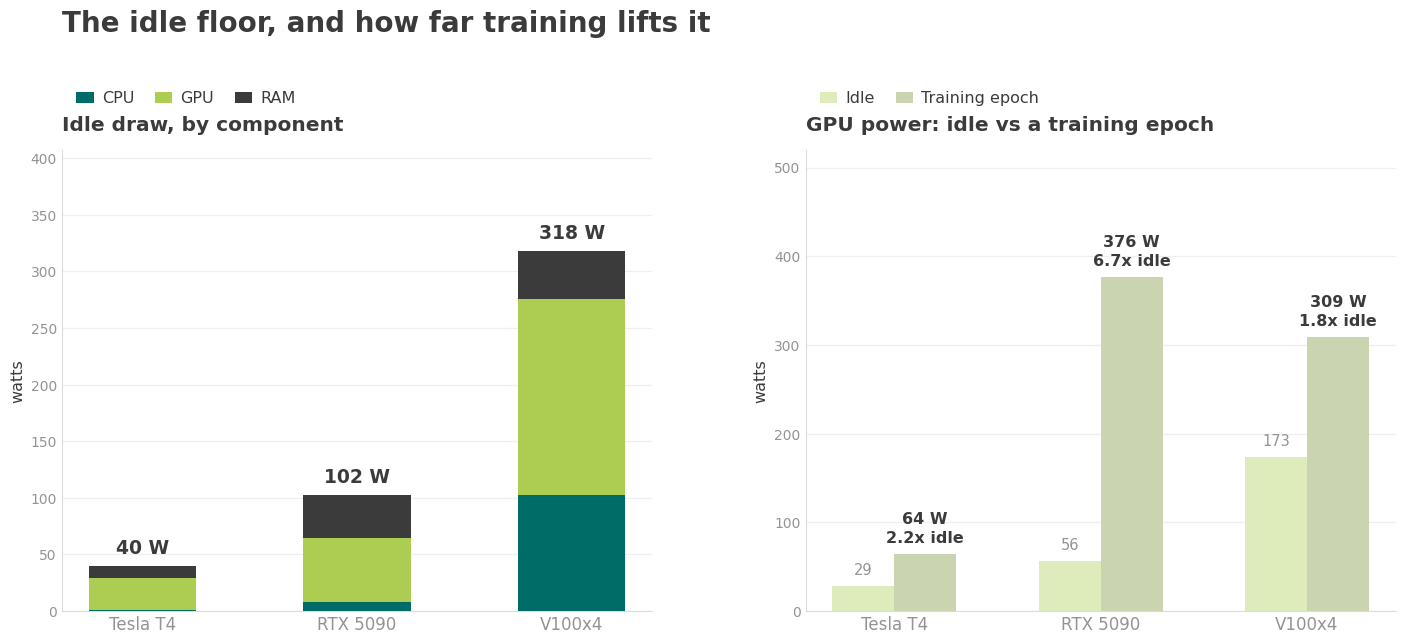

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 7.2))
fig.subplots_adjust(top=0.80, bottom=0.16, left=0.06, right=0.98, wspace=0.26)

idle_rows = {name: df[df.stage == "idle"].iloc[0] for name, df, _ in DEVICES}

# ---- left: idle draw by component (stacked bars) ----
ax = axes[0]
components = ["cpu_power_W", "gpu_power_W", "ram_power_W"]
comp_colors = [TEAL, OLIVE, INK]
comp_labels = ["CPU", "GPU", "RAM"]

x = np.arange(len(DEVICES))
bottoms = np.zeros(len(DEVICES))
for comp, color, label in zip(components, comp_colors, comp_labels):
    vals = np.array([idle_rows[name][comp] for name, _, _ in DEVICES])
    ax.bar(x, vals, bottom=bottoms, width=0.5, color=color, label=label, zorder=3)
    bottoms += vals

totals = bottoms
for xi, t in zip(x, totals):
    ax.text(xi, t + totals.max() * 0.025, f"{t:.0f} W", ha="center", va="bottom",
            fontsize=13.5, fontweight="bold", color=INK)

ax.set_xticks(x)
ax.set_xticklabels([d[0] for d in DEVICES], fontsize=12)
ax.set_ylabel("watts", fontsize=11.5)
ax.set_title("Idle draw, by component", loc="left", fontsize=14.5, fontweight="bold", pad=14)
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.16), frameon=False, ncols=3,
          fontsize=11.5, handlelength=1.1, columnspacing=1.3, handletextpad=0.5)
ax.set_ylim(0, totals.max() * 1.28)
style_ax(ax)

# ---- right: idle vs mean-training GPU power ----
ax = axes[1]
idle_vals = np.array([idle_rows[name]["gpu_power_W"] for name, _, _ in DEVICES])
train_vals = np.array([df[df.stage == "training_epoch"]["gpu_power_W"].mean() for _, df, _ in DEVICES])

width = 0.30
xg = np.arange(len(DEVICES))
for i, (name, df, color) in enumerate(DEVICES):
    ax.bar(xg[i] - width / 2, idle_vals[i], width=width, color=lighten(OLIVE, 0.6), zorder=3,
           label="Idle" if i == 0 else None)
    ax.bar(xg[i] + width / 2, train_vals[i], width=width, color=lighten(RUST, 0.6), zorder=3,
           label="Training epoch" if i == 0 else None)
    ratio = train_vals[i] / idle_vals[i]
    ax.text(xg[i] + width / 2, train_vals[i] + train_vals.max() * 0.025,
            f"{train_vals[i]:.0f} W\n{ratio:.1f}x idle", ha="center", va="bottom",
            fontsize=11.5, fontweight="bold", color=INK, linespacing=1.35)
    ax.text(xg[i] - width / 2, idle_vals[i] + train_vals.max() * 0.025, f"{idle_vals[i]:.0f}",
            ha="center", va="bottom", fontsize=10.5, color=GRAY)

ax.set_xticks(xg)
ax.set_xticklabels([d[0] for d in DEVICES], fontsize=12)
ax.set_ylabel("watts", fontsize=11.5)
ax.set_title("GPU power: idle vs a training epoch", loc="left", fontsize=14.5, fontweight="bold", pad=14)
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.16), frameon=False, ncols=2,
          fontsize=11.5, handlelength=1.1, columnspacing=1.3, handletextpad=0.5)
ax.set_ylim(0, train_vals.max() * 1.38)
style_ax(ax)

fig.text(0.06, 0.965, "The idle floor, and how far training lifts it",
         fontsize=20, fontweight="bold", color=INK)

# plt.savefig(f"{FIG_DIR}/plot1_idle_vs_training_power.png", dpi=170, bbox_inches="tight")
plt.show()

## Plot 2 - Training throughput and GPU power draw across the sweep

Left: training throughput (MB/s) vs. dataset size. Right: GPU power draw during training vs.
dataset size, with each device's idle floor marked as a dotted line.

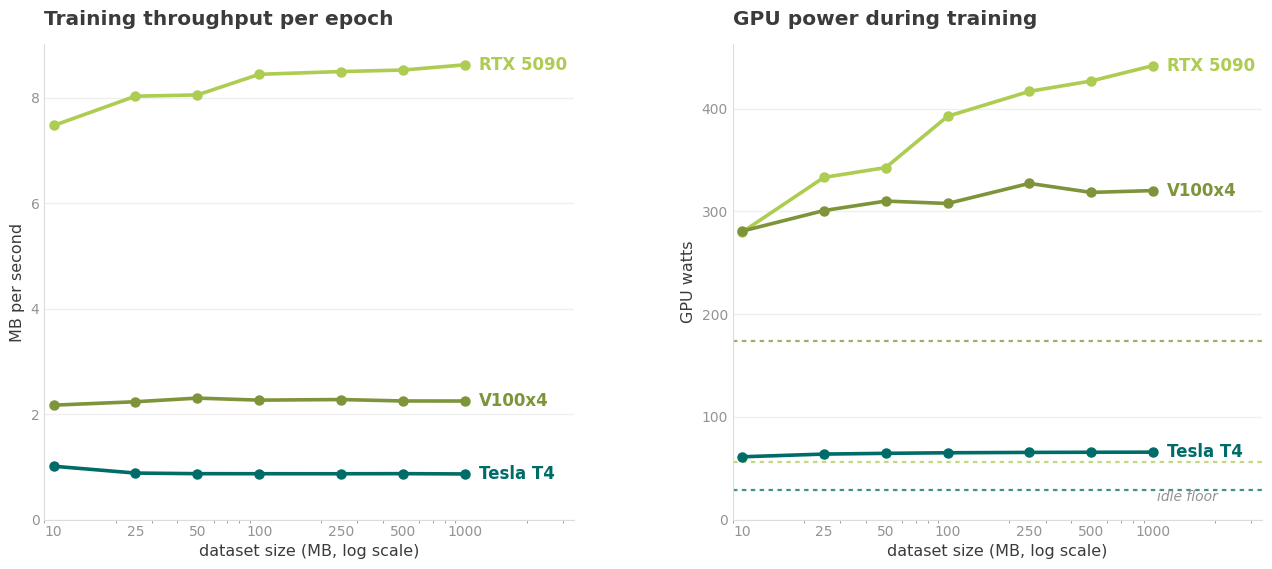

In [35]:
SIZE_TICKS = [10, 25, 50, 100, 250, 500, 1000]

fig, axes = plt.subplots(1, 2, figsize=(14.5, 7.2))
fig.subplots_adjust(top=0.80, bottom=0.14, left=0.06, right=0.90, wspace=0.30)

# ---- left: training throughput ----
ax = axes[0]
for name, df, color in DEVICES:
    g = (df[df.stage == "training_epoch"]
         .groupby("size_MB", as_index=False)["MB_per_s"].mean()
         .sort_values("size_MB"))
    ax.plot(g.size_MB, g.MB_per_s, marker="o", markersize=6.5, linewidth=2.6,
             color=color, zorder=3)
    xend, yend = g.size_MB.iloc[-1], g.MB_per_s.iloc[-1]
    ax.annotate(name, xy=(xend, yend), xytext=(10, 0), textcoords="offset points",
                 va="center", fontsize=12, fontweight="bold", color=color)

ax.set_xscale("log")
ax.set_xticks(SIZE_TICKS)
ax.get_xaxis().set_major_formatter(FuncFormatter(lambda v, _: f"{int(v)}"))
ax.set_xlim(9, 1000 * 3.4)
ax.set_xlabel("dataset size (MB, log scale)", fontsize=11.5)
ax.set_ylabel("MB per second", fontsize=11.5)
ax.set_title("Training throughput per epoch", loc="left", fontsize=14.5, fontweight="bold", pad=14)
ax.set_ylim(0, None)
style_ax(ax)

# ---- right: GPU power draw during training ----
ax = axes[1]
for name, df, color in DEVICES:
    g = (df[df.stage == "training_epoch"]
         .groupby("size_MB", as_index=False)["gpu_power_W"].mean()
         .sort_values("size_MB"))
    ax.plot(g.size_MB, g.gpu_power_W, marker="o", markersize=6.5, linewidth=2.6,
             color=color, zorder=3)
    idle_p = idle_rows[name]["gpu_power_W"]
    ax.axhline(idle_p, color=color, linestyle=(0, (2, 2)), linewidth=1.6, alpha=0.75, zorder=2)
    xend, yend = g.size_MB.iloc[-1], g.gpu_power_W.iloc[-1]
    ax.annotate(name, xy=(xend, yend), xytext=(10, 0), textcoords="offset points",
                 va="center", fontsize=12, fontweight="bold", color=color)

ax.text(1000 * 1.05, idle_rows["Tesla T4"]["gpu_power_W"] * 0.62, "idle floor", fontsize=10, color=GRAY,
         style="italic")

ax.set_xscale("log")
ax.set_xticks(SIZE_TICKS)
ax.get_xaxis().set_major_formatter(FuncFormatter(lambda v, _: f"{int(v)}"))
ax.set_xlim(9, 1000 * 3.4)
ax.set_xlabel("dataset size (MB, log scale)", fontsize=11.5)
ax.set_ylabel("GPU watts", fontsize=11.5)
ax.set_title("GPU power during training ", loc="left", fontsize=14.5, fontweight="bold", pad=14)
ax.set_ylim(0, None)
style_ax(ax)

# fig.text(0.06, 0.965, "Throughput and power across the sweep", fontsize=20, fontweight="bold", color=INK)

# fig.text(0.06, 0.905,
#           "Mean per training epoch at each dataset size",
#           fontsize=11.5, color=GRAY)

# plt.savefig(f"{FIG_DIR}/plot2_throughput_and_power.png", dpi=170, bbox_inches="tight")
plt.show()

## Plot 3 - Decompression Pareto front: runtime vs. CO2 per GB

One point per decompression run, normalised per GB processed, log-log. Marker size is the
compression ratio achieved. The MacBook's CPU codecs (zstd, lzma) are highlighted since they
sit in a completely different part of the plot to the neural GPU runs.

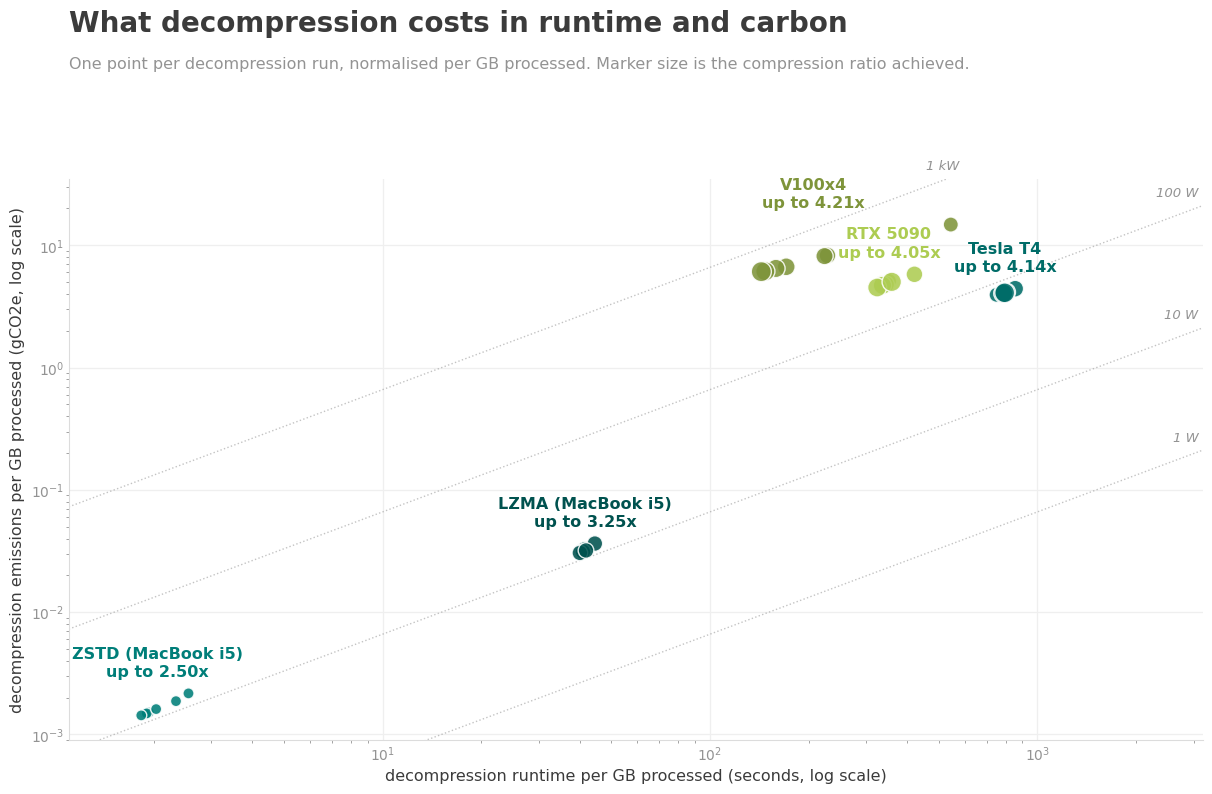

In [46]:
def add_per_gb(df, stage):
    d = df[df.stage == stage].copy()
    d["gb"] = d["input_bytes"] / 1e9
    d["runtime_per_gb"] = d["runtime_s"] / d["gb"]
    d["gco2_per_gb"] = d["emissions_kgCO2eq_per_GB"] * 1000.0
    return d

dec_t4   = add_per_gb(df_t4, "decompression")
dec_rtx  = add_per_gb(df_rtx, "decompression")
dec_v100 = add_per_gb(df_v100, "decompression")
dec_mac  = add_per_gb(df_mac, "decompression")
dec_zstd = dec_mac[dec_mac.codec == "zstd"]
dec_lzma = dec_mac[dec_mac.codec == "lzma"]

# grid carbon intensity, kg CO2 / kWh (constant across runs -- GBR grid)
intensity = (df_t4.loc[df_t4.stage == "decompression", "emissions_kgCO2eq"]
             / df_t4.loc[df_t4.stage == "decompression", "energy_kWh"]).mean()

def size_from_ratio(ratio):
    return 55 + (ratio - 2.4) * 85

fig, ax = plt.subplots(figsize=(13.5, 9.2))
fig.subplots_adjust(top=0.78, bottom=0.17, left=0.08, right=0.92)

XLIM = (1.1, 3200)
YLIM = (0.0009, 35)

all_groups = [
    ("Tesla T4",   dec_t4,   TEAL,               "o"),
    ("RTX 5090",   dec_rtx,  OLIVE,              "o"),
    ("V100x4",     dec_v100, RUST,               "o"),
    ("ZSTD (MacBook i5)", dec_zstd, PLUM,               "o"),
    ("LZMA (MacBook i5)", dec_lzma, darken(PLUM, 0.35), "o"),
]
for name, d, color, marker in all_groups:
    ax.scatter(d.runtime_per_gb, d.gco2_per_gb, s=size_from_ratio(d.compression_ratio),
                color=color, marker=marker, alpha=0.88, edgecolor="white", linewidth=1.0,
                zorder=4, label=name)
    lx = np.exp(np.log(d.runtime_per_gb).mean())
    ly = d.gco2_per_gb.max()
    ax.annotate(f"{name}\nup to {d.compression_ratio.max():.2f}x", xy=(lx, ly), xytext=(0, 12),
                 textcoords="offset points", ha="center", fontsize=11.5, fontweight="bold",
                 color=color, linespacing=1.3, zorder=6)

# ---- constant-power reference diagonals ----
xr = np.array(XLIM)
for P, label in [(1, "1 W"), (10, "10 W"), (100, "100 W"), (1000, "1 kW")]:
    yr = P * xr * intensity / 3600.0
    ax.plot(xr, yr, linestyle=":", color=GRAY, linewidth=1.0, alpha=0.55, zorder=1)
    y_at_xmax = P * XLIM[1] * intensity / 3600.0
    if y_at_xmax <= YLIM[1]:
        lx, ly = XLIM[1], y_at_xmax
        ha = "right"
    else:
        lx = YLIM[1] * 3600.0 / (P * intensity)
        ly = YLIM[1]
        ha = "center"
    ax.text(lx * 0.97, ly * 1.12, label, fontsize=9.5, color=GRAY, ha=ha, va="bottom", style="italic", zorder=1)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.set_xlabel("decompression runtime per GB processed (seconds, log scale)", fontsize=11.5)
ax.set_ylabel("decompression emissions per GB processed (gCO2e, log scale)", fontsize=11.5)
style_ax(ax, grid_axis="both")

fig.text(0.08, 0.94, "What decompression costs in runtime and carbon", fontsize=20, fontweight="bold", color=INK)
fig.text(0.08, 0.90,
          "One point per decompression run, normalised per GB processed. Marker size is the compression ratio achieved.",
          fontsize=11.5, color=GRAY)
plt.show()

## Plot 4 - Carbon cost vs. input size, one panel per GPU

One row, three columns - Tesla T4, RTX 5090, V100x4 - each showing carbon emissions
(gCO2e, log scale) against input size (MB, log scale). Training is per-epoch carbon
(mean over that size's epochs); compression and decompression are per full run - there's
only one of each per size, so there's no "epoch" to average. Labels on the training line
at 10 MB and 1000 MB give the mean epoch runtime at those sizes.

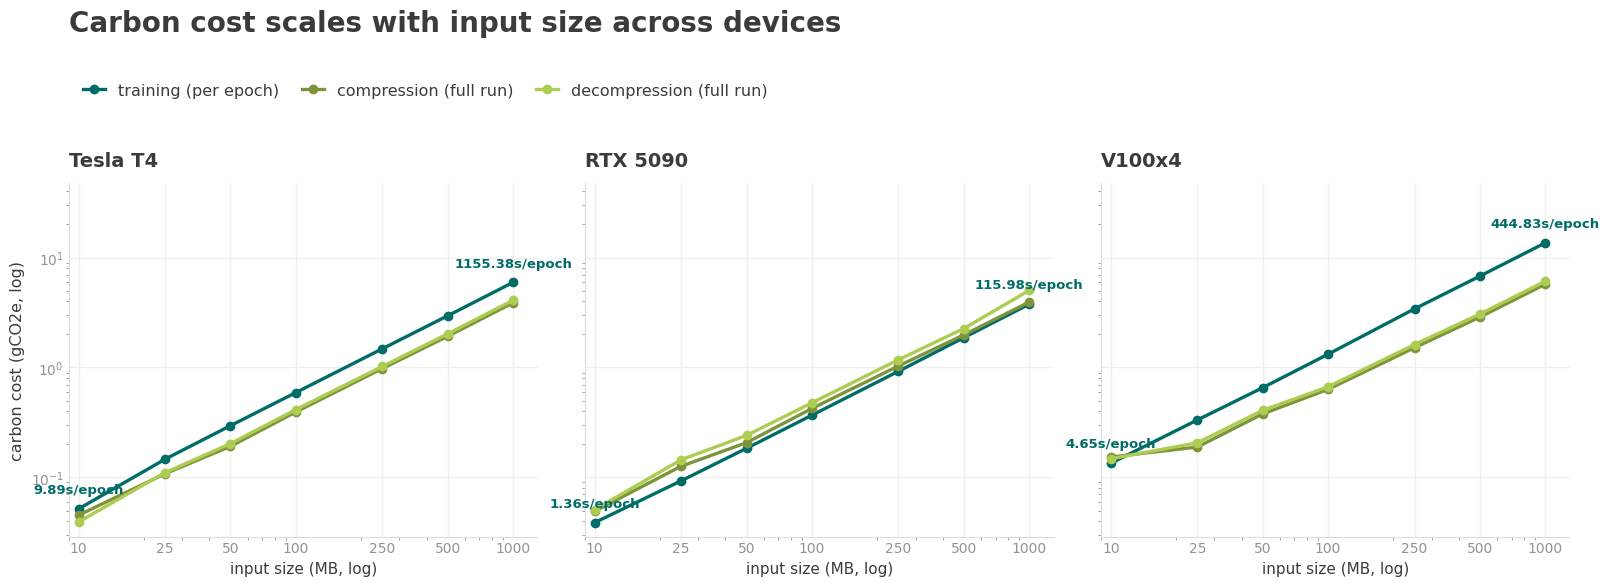

In [25]:
STAGE_STYLE = {
    "training_epoch": ("training (per epoch)",    TEAL),
    "compression":    ("compression (full run)",  RUST),
    "decompression":  ("decompression (full run)", OLIVE),
}

fig, axes = plt.subplots(1, 3, figsize=(16.5, 6.2), sharey=True)
fig.subplots_adjust(top=0.72, bottom=0.15, left=0.07, right=0.98, wspace=0.10)

ANNOTATE_SIZES = [10, 1000]

for ax, (name, df, _) in zip(axes, DEVICES):
    for stage, (label, color) in STAGE_STYLE.items():
        g = (df[df.stage == stage]
             .groupby("size_MB", as_index=False)
             .agg(emissions_kgCO2eq=("emissions_kgCO2eq", "mean"),
                  runtime_s=("runtime_s", "mean"))
             .sort_values("size_MB"))
        if g.empty:
            continue
        ax.plot(g.size_MB, g.emissions_kgCO2eq * 1000.0, marker="o", markersize=6,
                 linewidth=2.4, color=color, label=label, zorder=3)

        if stage == "training_epoch":
            for sz in ANNOTATE_SIZES:
                row = g[g.size_MB == sz]
                if row.empty:
                    continue
                x = row.size_MB.iloc[0]
                y = row.emissions_kgCO2eq.iloc[0] * 1000.0
                rt = row.runtime_s.iloc[0]
                ax.annotate(f"{rt:.2f}s/epoch", xy=(x, y), xytext=(0, 9),
                            textcoords="offset points", ha="center", va="bottom", fontsize=9.5,
                            fontweight="bold", color=color, zorder=6)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks(SIZE_TICKS)
    ax.get_xaxis().set_major_formatter(FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.set_xlim(9, 1000 * 1.3)
    ax.set_xlabel("input size (MB, log)", fontsize=11)
    ax.set_title(name, loc="left", fontsize=14, fontweight="bold", pad=12)
    style_ax(ax, grid_axis="both")

ymin, ymax = axes[0].get_ylim()
axes[0].set_ylim(ymin, ymax * 2.6)

axes[0].set_ylabel("carbon cost (gCO2e, log)", fontsize=11.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.07, 0.905), frameon=False,
           ncols=3, fontsize=11.5, handlelength=1.4, columnspacing=1.4)

fig.text(0.07, 0.965, "Carbon cost scales with input size across devices",
          fontsize=20, fontweight="bold", color=INK)

# plt.savefig(f"{FIG_DIR}/plot4_carbon_vs_size.png", dpi=170, bbox_inches="tight")
plt.show()